# How to use EnergyMeter
EnergyMeter allows us to measure the energy consumption of code on Python, segregating their energy usage per component (CPU, DRAM, GPU and 
Hard Disk).

We will first introduce how to use EnergyMeter with a minimal example in which we will use numpy to perform some calculations. We create the EnergyMeter by giving it the parameters of the energy consumption of the hard drive and we also give it a label, that will be used to report the results later on.

All we need to do afterwards, is to run meter.begin() before running the code we want to measure and meter.end() after running the code.

In [1]:
!pip install . --quiet
from energymeter import EnergyMeter
import time
import numpy as np

meter = EnergyMeter(disk_avg_speed=1600*1e6, 
                            disk_active_power=6, 
                            disk_idle_power=1.42, 
                            label="Matrix Multiplication", include_idle=False)
meter.begin()
(np.random.rand(300,300)**5)*1/np.random.rand(300,300)
meter.end()


[notice] A new release of pip is available: 25.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


 You need to install pymongo>=3.9.0 in order to use MongoOutput 


We can now see how the energy was spent while running our code. For this, we can use the methods get_total_joules_per_component() or plot_total_joules_per_component() to check how much energy was spent while running the code and how the energy was distributed in the computer components.

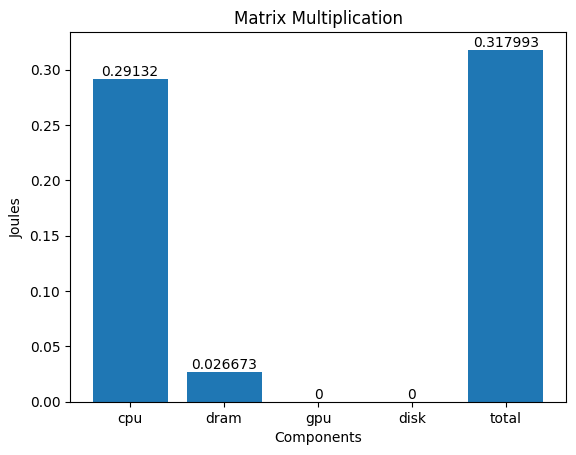

In [2]:
meter.plot_total_joules_per_component()

Note that even if our code did not write or read anything to disk, the plot indicates that the disk used some energy. This is because we also measure the energy used by the disk while being idle.

## A more interesting example
Let's test EnergyMeter in a more interesting example: measuring the energy consumption of performing inference with a Convolutional Neural Network, more specifically VGG16.

In [3]:
from urllib.request import urlopen
from PIL import Image
import timm
import torch
import json
import torchvision

transforms = torchvision.transforms.Compose([
    torchvision.transforms.transforms.Resize(size=256),
    torchvision.transforms.transforms.CenterCrop(size=(224, 224)),
    torchvision.transforms.transforms.ToTensor(),
    torchvision.transforms.transforms.Normalize(mean=torch.Tensor([0.4850, 0.4560, 0.4060]), 
                                                 std=torch.Tensor([0.2290, 0.2240, 0.2250])),
])

# the json file where the output must be stored

json_file = open("./imagenet-simple-labels.json", "r")
imagenet_dict = json.load(json_file)
json_file.close()

def predict(model, img):
    output = model(img)
    top5_probabilities, top5_class_indices = torch.topk(output.softmax(dim=1) * 100, k=5)
    return top5_probabilities, top5_class_indices.tolist()[0]

def preprocess_data(img):
    # unsqueeze single image into batch of 1.
    return transforms(img).unsqueeze(0)

model = timm.create_model('vgg16.tv_in1k', pretrained=True)
model = model.eval()
model

# If we run this twice, the GPU seems to be preprocessing the image when
# we run the CPU test. In order to avoid it, it's necessary to load the
# model again, so it seems something remains in the GPU even after running
# model.to("cpu").

img = Image.open(urlopen(
    'https://unsplash.com/photos/DwxlhTvC16Q/download?ixid=M3wxMjA3fDB8MXxzZWFyY2h8MXx8bWVyY2VkZXMlMjBjYXJ8ZW58MHx8fHwxNjg2NzA1MzUyfDA&force=true&w=640'
))

# CPU
# Disk in test has an avg i/o speed of 1600MB/s and 
# a power consumption of 6W when active and 1.42W when idle.
meter_cpu = EnergyMeter(disk_avg_speed=1600*1e6, 
                        disk_active_power=6, 
                        disk_idle_power=1.42, 
                        label="CPU Inference")
model = model.to("cpu")

meter_cpu.begin()
for _ in range(200):
    p_img = preprocess_data(img).to("cpu")
    probs, labels = predict(model, p_img)
meter_cpu.end()

# To ensure samples from GPU power stats are not mixed up.
time.sleep(1)

meter_gpu = EnergyMeter(disk_avg_speed=1600*1e6, 
                        disk_active_power=6, 
                        disk_idle_power=1.42, 
                        label="GPU Inference")
model = model.to("cuda:0")
meter_gpu.begin()
for _ in range(20):
    p_img = preprocess_data(img).to("cuda:0")
    probs, labels = predict(model, p_img)
meter_gpu.end()

/local/mfadel/miniconda3/envs/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


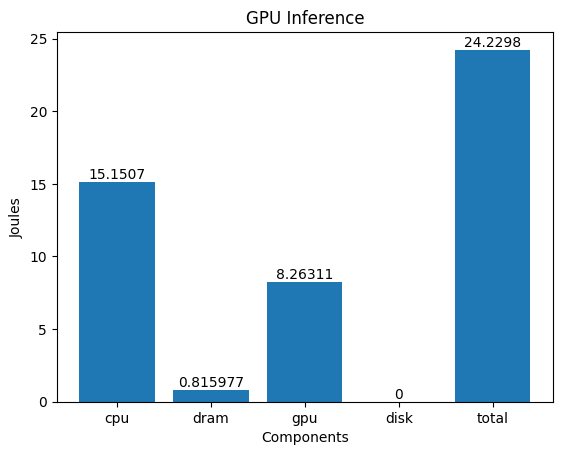

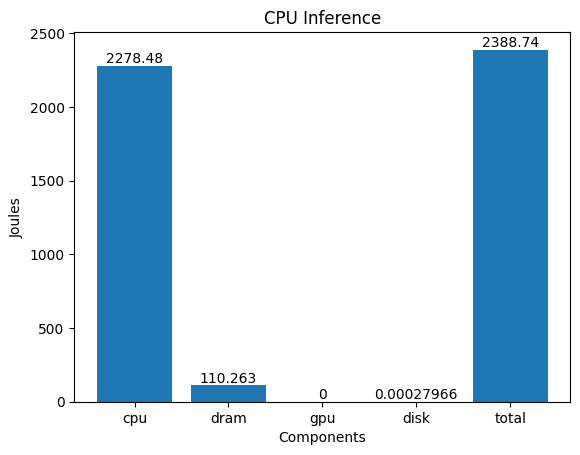

In [4]:
meter_gpu.plot_total_joules_per_component()
meter_cpu.plot_total_joules_per_component()

# The overhead of EnergyMeter
We test the overhead of using the EnergyMeter. For this, we run inference for 100 and 1000 times with and without the EnergyMeter.

In [5]:
def inference(model, img, n_inference):
    for _ in range(n_inference):
        p_img = preprocess_data(img).to("cuda:0")
        probs, labels = predict(model, p_img)

In [6]:
meter_overhead = EnergyMeter(disk_avg_speed=1600*1e6, 
                            disk_active_power=6, 
                            disk_idle_power=1.42, 
                            label="Inference 100")
meter_overhead.begin()
%timeit inference(model, img, n_inference=100)
meter_overhead.end()

497 ms ± 3.67 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [7]:
%timeit inference(model, img, n_inference=100)

496 ms ± 272 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [8]:
meter_overhead = EnergyMeter(disk_avg_speed=1600*1e6, 
                            disk_active_power=6, 
                            disk_idle_power=1.42, 
                            label="Inference 1000")
meter_overhead.begin()
%timeit inference(model, img, n_inference=1000)
meter_overhead.end()

4.95 s ± 4.48 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [9]:
%timeit inference(model, img, n_inference=1000)

4.93 s ± 2.37 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


#### We see that the EnergyMeter adds no significant overhead.

For 100 samples, the overhead is so small that it does not affect the mean, only the standard deviation.

For 1000 samples, we estimate the overhead doing 4.95/4.93=1,00406 ==> less than 1% overhead.
